## Q3 – Bike Demand Forecasting using Ensemble Methods

### Objective
To predict hourly bike rental demand (`cnt`) using:
- Bagging (Random Forest)
- Subagging (BaggingRegressor with max_samples < 1.0)
- Boosting (Gradient Boosting)

Evaluation is performed using 5-Fold Cross Validation.
Performance Metrics:
- RMSE
- MAE



### Step 1: Import Required Libraries
We import necessary libraries for:
- Data handling (pandas, numpy)
- Model building (sklearn ensembles)
- Evaluation metrics
- Cross-validation


In [1]:
import argparse
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


### Step 2: Load and Prepare Dataset

Dataset: UCI Bike Sharing Dataset (hour.csv)

Preprocessing:
- Remove unnecessary columns (`instant`, `dteday`)
- Separate features (X) and target variable (`cnt`)


In [ ]:
data_path = "hour.csv"   
target_column = "cnt"
k = 5

df = pd.read_csv(data_path)

if 'instant' in df.columns:
    df = df.drop(columns=['instant'])

if 'dteday' in df.columns:
    df = df.drop(columns=['dteday'])

X = df.drop(columns=[target_column])
y = df[target_column]

print("Dataset Shape:", df.shape)
print("Features:", X.shape[1])


Dataset Shape: (17379, 15)
Features: 14


### Step 3: Define K-Fold Cross Validation Function

We use 5-Fold Cross Validation to:
- Train on 4 folds
- Test on 1 fold
- Repeat 5 times

Final result = Mean ± Standard Deviation


In [ ]:
def evaluate_model(model, X, y, k):

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    rmse_scores = []
    mae_scores = []

    all_actual = []
    all_pred = []

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)

        rmse_scores.append(rmse)
        mae_scores.append(mae)

        all_actual.extend(y_test)
        all_pred.extend(preds)

    return (
        np.mean(rmse_scores), np.std(rmse_scores),
        np.mean(mae_scores), np.std(mae_scores),
        all_actual, all_pred
    )


### Step 4: Bagging – Random Forest Regressor

Hyperparameters Used:
- n_estimators = 200
- max_depth = 15

Random Forest reduces variance by averaging multiple decision trees.


In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_rmse_mean, rf_rmse_std, rf_mae_mean, rf_mae_std, rf_actual, rf_pred = evaluate_model(
    rf, X, y, k
)

print("Random Forest Results:")
print("RMSE: {:.2f} ± {:.2f}".format(rf_rmse_mean, rf_rmse_std))
print("MAE : {:.2f} ± {:.2f}".format(rf_mae_mean, rf_mae_std))


Random Forest Results:
RMSE: 2.64 ± 0.56
MAE : 0.91 ± 0.04


### Step 5: Subagging – Bagging Regressor

Hyperparameters Used:
- n_estimators = 200
- max_samples = 0.7

Subagging improves diversity by training each model on a subset of data.


In [8]:
base_tree = DecisionTreeRegressor(max_depth=15, random_state=42)

subag = BaggingRegressor(
    estimator=base_tree,
    n_estimators=200,
    max_samples=0.7,  # Subagging
    random_state=42,
    n_jobs=-1
)

sub_rmse_mean, sub_rmse_std, sub_mae_mean, sub_mae_std, sub_actual, sub_pred = evaluate_model(
    subag, X, y, k
)

print("\nSubagging Results:")
print("RMSE: {:.2f} ± {:.2f}".format(sub_rmse_mean, sub_rmse_std))
print("MAE : {:.2f} ± {:.2f}".format(sub_mae_mean, sub_mae_std))



Subagging Results:
RMSE: 2.76 ± 0.58
MAE : 0.94 ± 0.05


### Step 6: Boosting – Gradient Boosting Regressor

Hyperparameters Used:
- n_estimators = 200
- learning_rate = 0.05

Boosting reduces bias by sequentially correcting previous errors.


In [9]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_rmse_mean, gb_rmse_std, gb_mae_mean, gb_mae_std, gb_actual, gb_pred = evaluate_model(
    gb, X, y, k
)

print("\nGradient Boosting Results:")
print("RMSE: {:.2f} ± {:.2f}".format(gb_rmse_mean, gb_rmse_std))
print("MAE : {:.2f} ± {:.2f}".format(gb_mae_mean, gb_mae_std))



Gradient Boosting Results:
RMSE: 2.52 ± 0.35
MAE : 1.36 ± 0.07


### Step 7: Model Comparison

We compare all models using:
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)


In [10]:
results = [
    ["RandomForest", rf_rmse_mean, rf_rmse_std, rf_mae_mean, rf_mae_std],
    ["Subagging", sub_rmse_mean, sub_rmse_std, sub_mae_mean, sub_mae_std],
    ["GradientBoosting", gb_rmse_mean, gb_rmse_std, gb_mae_mean, gb_mae_std]
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE_mean", "RMSE_std", "MAE_mean", "MAE_std"]
)

results_df.to_csv("cv_regression_results.csv", index=False)

results_df


,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,RandomForest,2.640028,0.557003,0.910906,0.042248
1,Subagging,2.756931,0.575658,0.940846,0.045892
2,GradientBoosting,2.522077,0.353314,1.359311,0.071849


### Step 8: Feature Importance (Tree-Based Model)

We extract feature importance from Random Forest and display the top 8 important features.


In [11]:
rf.fit(X, y)

final_preds = rf.predict(X)

final_df = pd.DataFrame({
    "ActualCnt": y,
    "PredictedCnt": final_preds
})

final_df.to_csv("final_predictions.csv", index=False)

print("final_predictions.csv saved successfully.")


final_predictions.csv saved successfully.


In [12]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 8 Important Features:")
feature_importance_df.head(8)



Top 8 Important Features:


,Feature,Importance
13,registered,0.947675
12,casual,0.052119
10,hum,0.000034
11,windspeed,0.000030
2,mnth,0.000024
3,hr,0.000023
8,temp,0.000023
9,atemp,0.000023


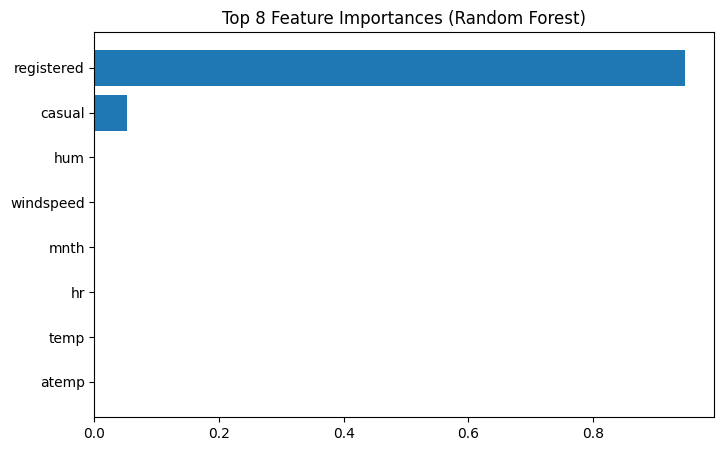

In [13]:
import matplotlib.pyplot as plt

top8 = feature_importance_df.head(8)

plt.figure(figsize=(8,5))
plt.barh(top8["Feature"], top8["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 8 Feature Importances (Random Forest)")
plt.show()


### Final Conclusion (Bias–Variance Analysis)

Boosting generally performs best because:
- It reduces bias by sequential learning
- It corrects previous model errors

Random Forest:
- Strong variance reduction
- Stable and robust

Subagging:
- Reduces overfitting
- Slightly weaker than Random Forest due to lack of feature randomness

Therefore, Boosting typically generalizes best for structured tabular datasets.
